In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [88]:
root_data = Path("./data")
processed_dir = root_data / "processed"

keywords = ["data", "queich", "pet"]
csv_paths = {
    f.stem: f for f in root_data.rglob("*.csv") 
    if any(k in f.name for k in keywords)
    }

subset_date = "2005-01-01"

Saved dataframe to data\processed\discharge_queich_siebeldingen.csv!


<Axes: xlabel='date'>

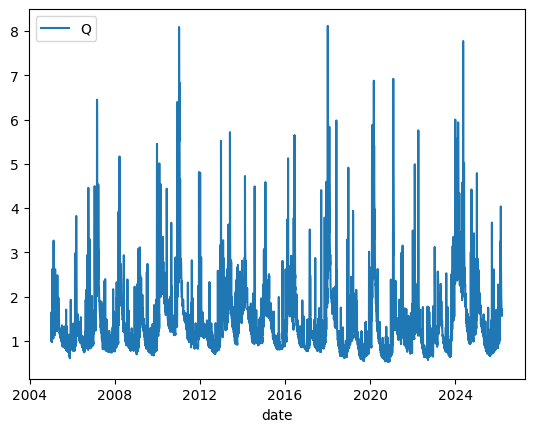

In [103]:
# --- Discharge ---
def process_discharge_data(
    path: str | Path,
    output_dir: str | Path | None = None,
    filename: str | None = "discharge_queich_siebeldingen"
    ) -> pd.DataFrame:
    
    df = pd.read_csv(path, sep=",", decimal=",")
    
    # Subset weird df for discharge and reset index
    df = df[df["Parameter"] == "Abfluss am Pegel"]
    df = df.reset_index(drop=True)

    # Create subset of copy
    df = df[["Datum", "Wert"]].copy()
    df.columns = ["date", "Q"]

    # To datetime and subset
    df["date"] = pd.to_datetime(df["date"], format="%d.%m.%Y")
    df = df[df["date"] > subset_date]
    df["date"] = df["date"].dt.date
    
    # Clean index and set date as index
    df = df.sort_values(by="date")
    df = df.reset_index(drop=True)
    df = df.set_index("date")
    
    if output_dir:
        output_path = Path(output_dir) / f"{filename}.csv"
        df.to_csv(output_path, sep=",")
        print(f"Saved dataframe to {output_path}!")
        
    return df

# Read discharge data
discharge_path = csv_paths["abfluss_queich_siebeldingen"]

# Process and plot discharge data
df_discharge = process_discharge_data(
    path=discharge_path,
    output_dir=processed_dir
    )

df_discharge.plot()

<Axes: xlabel='date'>

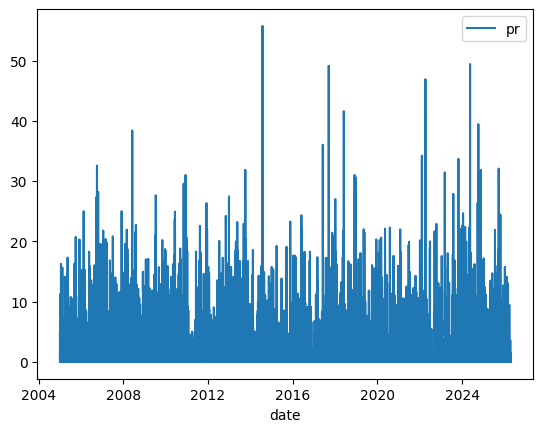

In [104]:
# --- Hyras precipitation ---
hyras_path = csv_paths["precip_mean_queich_watershed"]
df_precip = pd.read_csv(filepath_or_buffer=hyras_path, sep=",")

df_precip["date"] = pd.to_datetime(df_precip["date"], format="%Y-%m-%d %H:%M:%S")
df_precip = df_precip[df_precip["date"] > subset_date]
df_precip["date"] = df_precip["date"].dt.date

df_precip = df_precip.reset_index(drop=True)
df_precip = df_precip.set_index("date")
df_precip.plot()

<Axes: xlabel='date'>

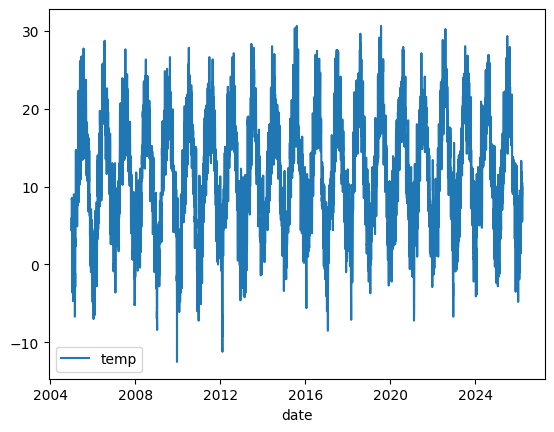

In [171]:
temp_path = csv_paths["data_OBS_DEU_P1D_T2M_377"]


df_temp = pd.read_csv(filepath_or_buffer=temp_path, sep=",", index_col=False)
df_temp = df_temp[["Zeitstempel", "Wert"]]

df_temp.columns = ["date", "temp"]

df_temp["date"] = pd.to_datetime(df_temp["date"], format="%Y-%m-%d")
df_temp = df_temp[df_temp["date"] > subset_date]
df_temp["date"] = df_temp["date"].dt.date

df_temp = df_temp.set_index("date")
df_temp.plot()

In [246]:
dfs = [
    df_discharge,
    df_precip,
    df_temp
    ]

# dfs = [df.set_index("date") for df in dfs]    
# col_names = ["Q", "temp_bb", "precip_bb", "pet_bb"]

df_all = pd.concat(dfs, axis=1)
# df_all.columns = col_names
df_all

,Q,pr,temp
date,,,
2005-01-02,1.2105,0.251031,5.9
2005-01-03,0.9885,1.228866,4.3
2005-01-04,1.0754,0.023711,5.8
2005-01-05,1.1046,11.257732,4.7
2005-01-06,1.6392,0.173711,7.7
...,...,...,...
2026-04-16,NaN,0.000515,NaN
2026-04-17,NaN,0.000000,NaN
2026-04-18,NaN,1.339175,NaN


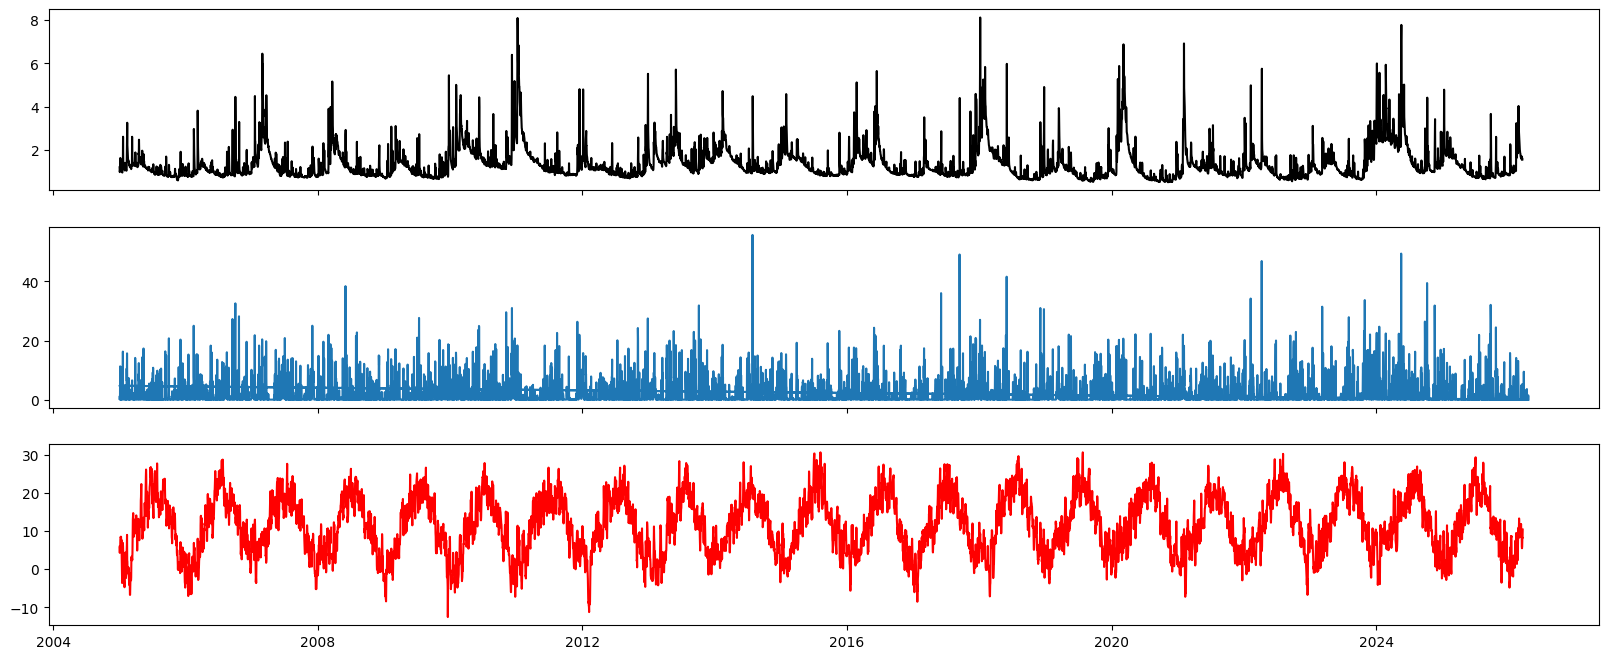

In [247]:
fig, axs = plt.subplots(nrows=3, figsize=(20, 8), sharex=True)

axs[0].plot(df_all["Q"], color = "black")
axs[1].plot(df_all["pr"])
axs[2].plot(df_all["temp"], color="red")

plt.show()

In [183]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

##### Add date transform, lag and sum to data

In [248]:
df_all.index = pd.to_datetime(df_all.index)

# Add sin cos date transform to data
df_all["doy_sin"] = np.sin(2*np.pi * df_all.index.dayofyear/365)
df_all["doy_cos"] = np.cos(2*np.pi * df_all.index.dayofyear/365)


for col in df_all.columns:
    if "pr" in col or "temp" in col or "pet" in col:
        for lag in range(1, 42):
            df_all[f"{col}_{lag}"] = df_all[col].shift(lag)
    
    if "pr" in col:
        for d in [3, 7, 14, 21, 28, 35, 42, 56]:
            df_all[f"{col}_sum_{d}"] = df_all[col].rolling(d).sum()

df_all["target"] = df_all["Q"].shift(-1)

df_all.dropna(inplace=True)


# Export to processed folder
output_path = root_data / "processed" / "df_all.csv"
df_all.to_csv(path_or_buf=output_path, sep=",")